# **Exploratory Data Analysis of Netflix Dataset: Trends, Engagement Patterns, and Content Characteristics**

#  **1. Introduction**

Streaming platforms such as Netflix host a wide range of content, varying in genre, duration, release year, and popularity. Understanding how these characteristics relate to viewer engagement can offer valuable insights into audience behaviour and content performance.

This project/task conducts an exploratory data analysis (EDA) of two Netflix datasets: one containing descriptive information about each title (such as type, country, release year, duration, and genre), and another containing viewer engagement metrics (viewer ratings and rating counts). After merging the datasets, the data was cleaned, transformed, and analysed to investigate relationships between key variables.

The objectives of this analysis are to examine engagement patterns across different release periods, to explore how viewer interaction varies by genre, and to assess whether the duration of a title influences its popularity. This process involved data preprocessing, visualisation, summary statistics, and the formulation of research questions to guide deeper interpretation of the findings.

# **2. Reading and Understanding the Data**

## **2.1 Load the datasets**
In this step, the two Netflix datasets (netflix_main.csv and netflix_ratings.csv) were loaded directly into the Google Colab environment using public Google Drive file IDs. This approach avoids the need to manually upload files each time the notebook is executed and ensures consistent access to the datasets.



In [ ]:
import pandas as pd

# -------------------------------------------------------------
# Load datasets from Google Drive using direct file download links
# -------------------------------------------------------------

# File IDs for the two datasets stored on Google Drive
# These IDs are unique identifiers that allow access to the files
main_file_id = "1xZJL1ytmtCnxMx4lMIoxXMYcmjAN8kGC"      # netflix_main.csv
ratings_file_id = "1msTuPG8tIOiuIiOg7idxLJ1dm4UibDTH"   # netflix_ratings.csv

# Construct direct-access URLs that allow Colab to download the CSV files
# Using uc?id=FILE_ID ensures the file downloads without needing manual upload
main_url = f"https://drive.google.com/uc?id={main_file_id}"
ratings_url = f"https://drive.google.com/uc?id={ratings_file_id}"

# Load the main and ratings datasets into pandas DataFrame
df_main = pd.read_csv(main_url)
df_ratings = pd.read_csv(ratings_url)

# -------------------------------------------------------------
# Preview the contents of each dataset to confirm correct loading
# -------------------------------------------------------------

# Show the first five rows of the main dataset in a clean table format
print("Main Dataset (first 5 rows):")
display(df_main.head())

print("\n---------------------------------------------\n")  # visual separator

# Show the first five rows of the ratings dataset
print("Ratings Dataset (first 5 rows):")
display(df_ratings.head())



Main Dataset (first 5 rows):


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



---------------------------------------------

Ratings Dataset (first 5 rows):


,show_id,viewer_rating,rating_count
0,s2,4.5,643
1,s3,4.3,1205
2,s4,3.9,2524
3,s5,4.8,298
4,s6,4.1,23320


### **2.1.1. Shapes of Main and Ratings Datasets**

The shape of a dataset shows how many rows (records) and columns (variables) it contains. The Main dataset consists of 8,367 rows and 12 columns, In contrast, the Ratings dataset contains 8,367 rows and 2 columns, providing viewer engagement information (viewer_rating and rating_count). Checking the shapes of both datasets ensures they contain the expected number of entries before merging and helps verify that no structural issues exist within the raw data.

In [ ]:
# Print the number of rows and columns in each dataset

print("Main dataset shape:", df_main.shape) # shape returns a tuple in the form (rows, columns)
print("Ratings dataset shape:", df_ratings.shape)

Main dataset shape: (8367, 12)
Ratings dataset shape: (8367, 3)


### **2.1.2 Column Names of Main and Ratings Datasets**

Checking the column names of each dataset helps understand the type of information available before any cleaning or merging. The Main dataset contains 12 columns , on the other hand the ratings dataset includes only two columns viewer_rating and rating_count which capture user engagement and rating behaviour. Reviewing the column names ensures clarity about the contents of each dataset and helps determine which variables are relevant for analysis and which should be selected or dropped during data cleaning.

In [ ]:
# print the column names of main dataset
print("Column names in Main Dataset:")
display(pd.DataFrame(df_main.columns, columns=["Main Dataset Columns"]))

# print the column names of ratings dataset
print("\nColumn names in Ratings Dataset:")
display(pd.DataFrame(df_ratings.columns, columns=["Ratings Dataset Columns"]))


Column names in Main Dataset:


,Main Dataset Columns
0,show_id
1,type
2,title
3,director
4,cast
5,country
6,date_added
7,release_year
8,rating
9,duration



Column names in Ratings Dataset:


,Ratings Dataset Columns
0,show_id
1,viewer_rating
2,rating_count


## **2.2  Merge the Main and Rating  Datasets**
The two datasets (netflix_main.csv and netflix_ratings.csv) were merged using the common key show_id to combine Netflix title information with viewer engagement metrics. Merging was necessary because the main dataset contained descriptive metadata about each title (such as type, title, country, release year, duration, and genre), while the second dataset provided viewer-generated fields (viewer_rating and rating_count). Combining them into a single dataset allows for a more complete analysis of how content characteristics relate to user engagement, which would not be possible if the files were analysed separately.

After merging the two datasets (netflix_main.csv and netflix_ratings.csv) using the shared key show_id, a combined dataset with 8,367 rows and 13 columns was obtained. The merged file includes Netflix title metadata (such as type, title, country, date added, release year, duration, and genre) along with viewer metrics (viewer_rating and rating_count).

Overall, the merged dataset provides complete coverage of Netflix titles and viewer interactions, but requires cleaning due to missing values, inconsistent formatting, and mixed data types. This merged file forms the basis for the following cleaning and exploratory analysis steps.

In [ ]:
# Merge the main dataset and ratings dataset using the common key 'show_id'
# 'how="left"' ensures all records from the main dataset are retained
df = df_main.merge(df_ratings, on="show_id", how="left")

# Display the first few rows of the merged dataset to confirm successful merging
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,viewer_rating,rating_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",4.5,643.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,4.3,1205.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",3.9,2524.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,4.8,298.0


## **2.3 Summary Of Merged Dataset**

### **2.3.1 Data Types of All Columns**

Reviewing the data types of all columns in the merged dataset helps determine how each variable should be handled during cleaning and analysis. Most columns, such as show_id, type, title, country, rating, duration, and listed_in, are stored as object types because they contain text-based information. The release_year column appears as an integer, reflecting its numerical nature, while rating_count is stored as a float, representing viewer engagement values.

In [ ]:
# Data Types of Each Column
print("Data Types for Each Column:\n")
print(df.dtypes)

Data Types for Each Column:

show_id           object
type              object
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
rating            object
duration          object
listed_in         object
description       object
viewer_rating     object
rating_count     float64
dtype: object


### **2.3.2 Unique Values in Each Column**

Checking the number of unique values in each column before cleaning helps identify the structure and characteristics of the dataset.Understanding the uniqueness of each column early on ensures that appropriate cleaning decisions can be made, such as selecting variables for analysis, identifying unnecessary features, and determining where grouping or transforming may be needed during preprocessing.

In [ ]:
# Summary: Number of Unique Values in Each Column
print("Unique Values in Each Column:\n")
print(df.nunique())

Unique Values in Each Column:

show_id          8367
type                2
title            8367
director         4344
cast             7310
country           721
date_added       1687
release_year       74
rating             17
duration          218
listed_in         511
description      8341
viewer_rating     228
rating_count     5238
dtype: int64


### **2.3.3 Missing Values in Each Column**

Checking missing values in the merged dataset is an essential step in understanding data completeness before any cleaning is performed. Identifying which columns contain gaps helps determine where additional preprocessing is required, such as imputing missing entries, standardising categories, or deciding whether certain variables should be removed. Missing values can also indicate data-quality issues, inconsistencies between the two datasets, or incomplete information for specific titles.

In [ ]:
#Summary: Missing Values for Each Column
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

show_id             0
type                0
title               0
director         2501
cast              792
country           791
date_added         10
release_year        0
rating              4
duration            3
listed_in           0
description         0
viewer_rating     652
rating_count      652
dtype: int64


# **Step 3: Data Cleaning and Wrangling**

# **3.1 Select Columns + Drop Unnecessary Ones**

In this step, a subset of variables was selected from the merged dataset to focus the analysis on fields that are most relevant for exploratory data analysis. A total of 11 columns were retained, including a mix of categorical and numerical variables such as type, country, release_year, duration, viewer_rating, and rating_count.

Columns considered less useful for the research questions, particularly long text fields such as description, director and cast were excluded at this stage. Removing unnecessary or high-missing-value columns reduces dataset complexity, improves readability, and ensures the subsequent analysis remains focused and efficient. The final selected dataset forms the basis for all cleaning, visualisation, and research question analysis in later steps.

In [ ]:
# Select a subset of relevant columns for analysis
# These variables include key identifiers, categorical attributes, date information, numerical engagement metrics, and genre details.
selected_columns = [
    'show_id', 'type', 'title', 'country', 'date_added',
    'release_year', 'rating', 'duration', 'listed_in',
    'viewer_rating', 'rating_count'
]

# Keep only the selected columns from the merged dataset
df = df[selected_columns]

# Display the first few rows to verify that the correct columns were retained
df.head()

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in,viewer_rating,rating_count
0,s1,Movie,Dick Johnson Is Dead,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,NaN,NaN
1,s2,TV Show,Blood & Water,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",4.5,643.0
2,s3,TV Show,Ganglands,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",4.3,1205.0
3,s4,TV Show,Jailbirds New Orleans,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",3.9,2524.0
4,s5,TV Show,Kota Factory,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",4.8,298.0


# **3.2 Handle Missing Values**
Several of the selected variables contained missing values, which needed to be addressed to ensure the dataset was complete and suitable for analysis. Since the focus of this task is exploratory analysis rather than predictive modelling, the priority was to retain as many rows as possible while preserving the interpretability of each variable.

Missing values in text-based columns such as country, date_added, rating, duration, and viewer_rating were replaced with meaningful placeholder labels (e.g., “unknown”, “unrated”, and “Unknown”). This approach prevents the loss of records and clearly distinguishes entries where information was not available. For the numerical variable rating_count, missing values were replaced with 0, indicating no recorded viewer engagement for those titles.

After applying these imputations, a second check using df.isnull().sum() confirmed that all missing values had been resolved within the selected variables. This step ensures consistency across the dataset and prepares it for accurate analysis in subsequent visualisation and exploration stages.

In [ ]:
# --------------------------------------------
# Handle missing values in the selected columns
# --------------------------------------------

# Replace missing country names with 'unknown'
# This keeps all rows while clearly marking unavailable information
df['country'] = df['country'].fillna('unknown')

# Replace missing dates with 'Unknown' to retain entries without a recorded date
df['date_added'] = df['date_added'].fillna('Unknown')

# Replace missing content ratings (e.g., PG, TV-MA) with 'unrated'
df['rating'] = df['rating'].fillna('unrated')

# Replace missing duration values with 'Unknown'
df['duration'] = df['duration'].fillna('Unknown')

# Replace missing viewer rating categories with 'Unknown'
df['viewer_rating'] = df['viewer_rating'].fillna('Unknown')

# Replace missing rating_count values with 0
# This assumes missing counts represent no recorded viewer engagement
df['rating_count'] = df['rating_count'].fillna(0)

# Verify that all missing values have been handled
df.isnull().sum()


,0
show_id,0
type,0
title,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0
viewer_rating,0


# **3.3.Remove Duplicates**
The dataset was checked for duplicate entries using the duplicated() function. Identifying duplicates is an important step in data cleaning because repeated records can distort summary statistics, correlations, and visualisations. The initial check printed the number of duplicated rows before removal, ensuring transparency in the cleaning process.

After this, the drop_duplicates() method was applied to remove any repeated rows from the dataset. A second check confirmed that no duplicate rows remained. This verification step ensures that each Netflix title appears only once in the dataset, maintaining the integrity of the analysis and preventing any bias caused by repeated records.

In [ ]:
# -------------------------------------------------------
# Check for and remove duplicate rows in the dataset
# -------------------------------------------------------

# Count how many duplicate rows exist before cleaning
duplicates_before = df.duplicated().sum()
print("Number of duplicate rows before removal:", duplicates_before)

# Remove any duplicated rows to ensure each title appears only once
df = df.drop_duplicates()

# Verify that all duplicates have been removed successfully
duplicates_after = df.duplicated().sum()
print("Number of duplicate rows after removal:", duplicates_after)

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


# **3.4 Convert Data Types**
Before cleaning, the variables were checked to confirm their original data types. Two columns required conversion. The date_added column was initially stored as text, so it was converted into a proper datetime format to allow time-based exploration. The duration column also contained mixed text values (e.g., “90 min”), so the numeric portion will extract into a new variable (in step 2.6 create new columns ) duration_numeric, which later can be used for numerical summaries and visualisations.

In [ ]:
# -----------------------------
# 2.4 Ensure Correct Data Types
# -----------------------------

# Display the data types of all columns before any conversions
print("Data types before conversion:\n")
print(df.dtypes)
print("\n--------------------------------\n")

# Convert 'date_added' from string/object format to a proper datetime type
# 'errors="coerce"' ensures invalid dates are converted to NaT instead of causing errors
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Display data types after conversions to confirm successful transformation
print("Data types after conversion:\n")
print(df.dtypes)

Data types before conversion:

show_id           object
type              object
title             object
country           object
date_added        object
release_year       int64
rating            object
duration          object
listed_in         object
viewer_rating     object
rating_count     float64
dtype: object

--------------------------------

Data types after conversion:

show_id                  object
type                     object
title                    object
country                  object
date_added       datetime64[ns]
release_year              int64
rating                   object
duration                 object
listed_in                object
viewer_rating            object
rating_count            float64
dtype: object


## **3.5 Standardise text columns**
Several text-based columns were standardised to ensure consistency across the dataset. This included converting values to lowercase and removing unnecessary spaces. Standardising text is important because inconsistencies in letter casing or spacing can lead to duplicated categories during grouping or visualisation. By applying the same formatting to columns such as title, country, rating, and listed_in, the dataset becomes cleaner, easier to analyse, and more reliable for summarising patterns

In [ ]:
# -----------------------------
# 2.5 Standardise Text Columns
# -----------------------------

# Define the text-based columns that require standardisation
text_columns = ['title', 'country', 'rating', 'listed_in']

# Convert all values in these columns to lowercase and remove extra spaces
for col in text_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Display the first few rows of the standardised text columns in a clean table format
print("Sample rows after text standardisation:\n")
display(df[text_columns].head())


Sample rows after text standardisation:



,title,country,rating,listed_in
0,dick johnson is dead,united states,pg-13,documentaries
1,blood & water,south africa,tv-ma,"international tv shows, tv dramas, tv mysteries"
2,ganglands,unknown,tv-ma,"crime tv shows, international tv shows, tv act..."
3,jailbirds new orleans,unknown,tv-ma,"docuseries, reality tv"
4,kota factory,india,tv-ma,"international tv shows, romantic tv shows, tv ..."


# **3.6 Create new columns**

Several new variables were created to enhance the dataset and make it more suitable for analysis. The original dataset included useful information, but some columns required transformation to enable statistical exploration and visualisation. Feature engineering improves the quality of the dataset by extracting meaningful numerical or categorical values from existing fields.

First, the duration column contained text values such as “90 min,” which could not be analysed numerically. To address this, the numeric portion of the duration was extracted and stored as a new variable, duration_numeric. This allows duration to be treated as a numeric variable and used in visualisations and statistical summaries.

Next, because titles often belong to multiple genres within the listed_in column, the first listed genre was extracted to create a simplified primary_genre variable. This helps group titles into clearer categories and supports comparisons across different genres.

Additionally, the date_added column includes full date information, but only the year was needed for analysis of time-based patterns. The year component was extracted to create a new variable, added_year, allowing the dataset to be examined by the year a title was added to Netflix.

In [ ]:
# --------------------------------------------------------
# Creating New Variables (Feature Engineering)
# --------------------------------------------------------

# 1. Create numeric duration variable
# Extract the numeric part from 'duration' (e.g. "90 min" → 90)
df['duration_numeric'] = df['duration'].str.extract(r'(\d+)').astype(float)

print("Preview of 'duration' and 'duration_numeric':\n")
display(df[['duration', 'duration_numeric']].head())

print("\n--------------------------------------------------\n")

# 2. Create primary genre variable
# Take only the first listed genre to simplify analysis
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

print("Preview of 'listed_in' and 'primary_genre':\n")
display(df[['listed_in', 'primary_genre']].head())

print("\n--------------------------------------------------\n")

# 3. Create added year variable
# Extract only the year from 'date_added' (datetime format required)
df['added_year'] = df['date_added'].dt.year

print("Preview of 'date_added' and 'added_year':\n")
display(df[['date_added', 'added_year']].head())

print("\n--------------------------------------------------\n")

# Display all column names WITH their data types
print("All column names with data types:\n")
display(df.dtypes.to_frame(name="Data Type"))

Preview of 'duration' and 'duration_numeric':



,duration,duration_numeric
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0



--------------------------------------------------

Preview of 'listed_in' and 'primary_genre':



,listed_in,primary_genre
0,documentaries,documentaries
1,"international tv shows, tv dramas, tv mysteries",international tv shows
2,"crime tv shows, international tv shows, tv act...",crime tv shows
3,"docuseries, reality tv",docuseries
4,"international tv shows, romantic tv shows, tv ...",international tv shows



--------------------------------------------------

Preview of 'date_added' and 'added_year':



,date_added,added_year
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0



--------------------------------------------------

All column names with data types:



,Data Type
show_id,object
type,object
title,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object
listed_in,object
viewer_rating,object


# **Step 4 - Data Exploration**

# **4.1 Summary Statistics**
Summary statistics were generated for the key numerical variables release_year, rating_count, and duration_numeric. Using the describe() function provides essential information such as the mean, median, minimum, maximum, and standard deviation for each variable. This helps to understand the overall distribution, identify potential outliers, and observe how spread out or concentrated the data is. These descriptive statistics form the foundation for deeper analysis and help guide further visual exploration in the next steps.

In [ ]:
# -----------------------------
#   Summary Statistics
# -----------------------------

# Define the numerical columns for summarising distribution and central tendency
numeric_cols = ['release_year', 'rating_count', 'duration_numeric']

print("Summary Statistics for Numeric Columns:\n")

# Generate summary statistics for the selected numeric columns
summary = df[numeric_cols].describe()

# Rename "50%" to "median" for clearer interpretation
summary = summary.rename(index={"50%": "median"})

# Display the summary statistics as a clean, formatted table
display(summary)

Summary Statistics for Numeric Columns:



,release_year,rating_count,duration_numeric
count,8367.000000,8367.000000,8364.000000
mean,2014.151667,4590.743516,69.821019
std,8.868717,6256.376931,50.805148
min,1925.000000,0.000000,1.000000
25%,2013.000000,1211.000000,2.000000
median,2017.000000,2678.000000,88.000000
75%,2019.000000,5568.000000,106.000000
max,2021.000000,101956.000000,312.000000


# **STEP 4.2 — Distribution Plots (Histograms & Boxplots) to identify outliers**

# **Histograms**
Histograms were used to visualise the distribution of the numerical variables (release_year, rating_count, and duration_numeric). By dividing each variable into bins, the histograms show how frequently different values occur. This helps identify patterns such as skewness, concentration of values, and potential outliers. For example, rating_count typically shows right-skewed behaviour due to a small number of highly popular titles. Histograms provide a clear overview of each variable’s spread before moving into deeper relationship analysis.


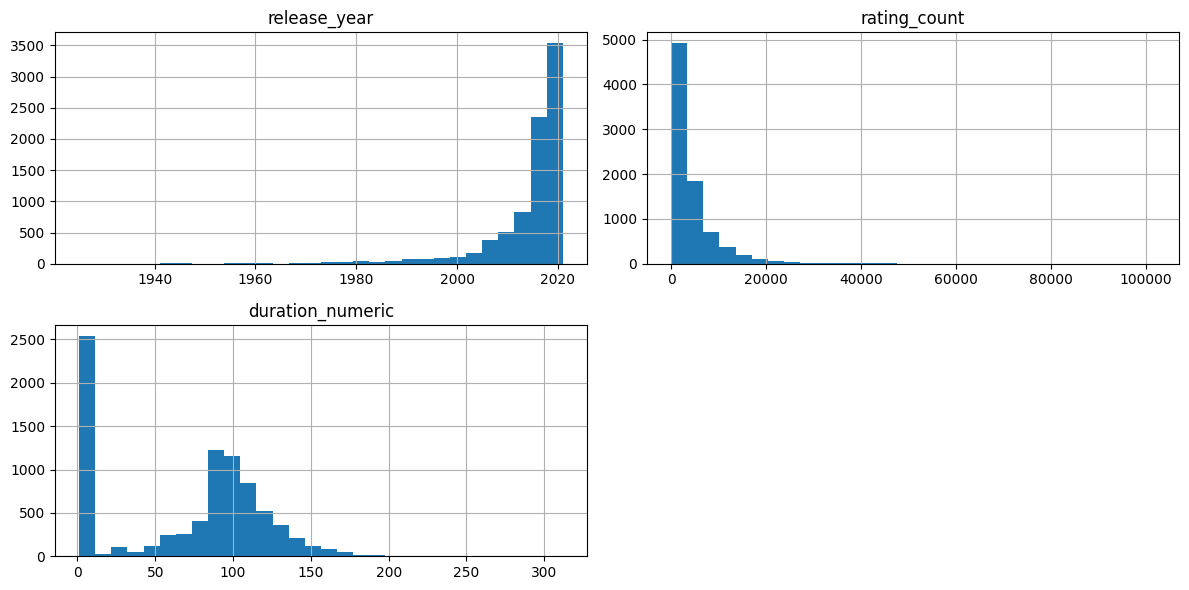

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------------
# Histograms for numeric variables
# -------------------------------------------

# Generate histograms for all selected numeric columns
# This helps visualise the distribution, spread, and skewness of each variable
df[numeric_cols].hist(figsize=(12, 6), bins=30)

# Adjust spacing between subplots to prevent overlapping labels
plt.tight_layout()

# Display the histograms
plt.show()

# **Boxplots**
Boxplots were created for the numerical variables (release_year, rating_count, and duration_numeric) to examine their distribution and detect potential outliers. Boxplots are useful because they highlight the median, interquartile range (IQR), and extreme values for each variable.

The boxplot revealed that rating_count contains a very large number of high-value outliers, caused by a small group of titles receiving exceptionally high audience engagement compared to the majority. This results in a highly skewed distribution, which is visually reflected in the tall vertical spread of points in the rating_count box. In contrast, release_year and duration_numeric show more compact ranges with fewer extreme values.

Although ***outliers are present, they were not removed***, because these high-engagement titles represent real viewer behaviour rather than data errors. Removing them would distort the dataset by artificially suppressing the popularity of successful titles. Therefore, the outliers were retained so the analysis accurately reflects genuine patterns in viewer engagement.


The rating_count variable shows several high-value outliers, where a small number of titles receive exceptionally large numbers of viewer ratings. These values were confirmed through both summary statistics and visual inspection, indicating a heavily right-skewed distribution.

Instead of removing these outliers, they were retained.

The decision is justified for the following reasons:


**1.** **Outliers represent genuine viewer behaviour**

The high rating counts belong to extremely popular Netflix titles (e.g., global hits or widely watched movies). These values are not mistakes or noise but reflect real engagement patterns. Removing them would distort the true distribution.

**2.** **Outliers provide meaningful insights**
Viewer engagement naturally varies widely across content. High-performing titles are important for understanding platform dynamics, genre appeal, and user behaviour. Excluding them would reduce the richness of the dataset.

**3. The aim of the analysis is descriptive, not predictive**
Since the task focuses on exploratory data analysis rather than building predictive models, retaining outliers allows for a more accurate representation of real-world viewer patterns. Outlier removal is more appropriate when extreme values negatively impact modelling performance, which is not the purpose here.

**4. No evidence suggests data errors**
Outliers do not result from data entry issues or incorrect formatting. They appear valid and consistent with known patterns of highly popular shows and movies.

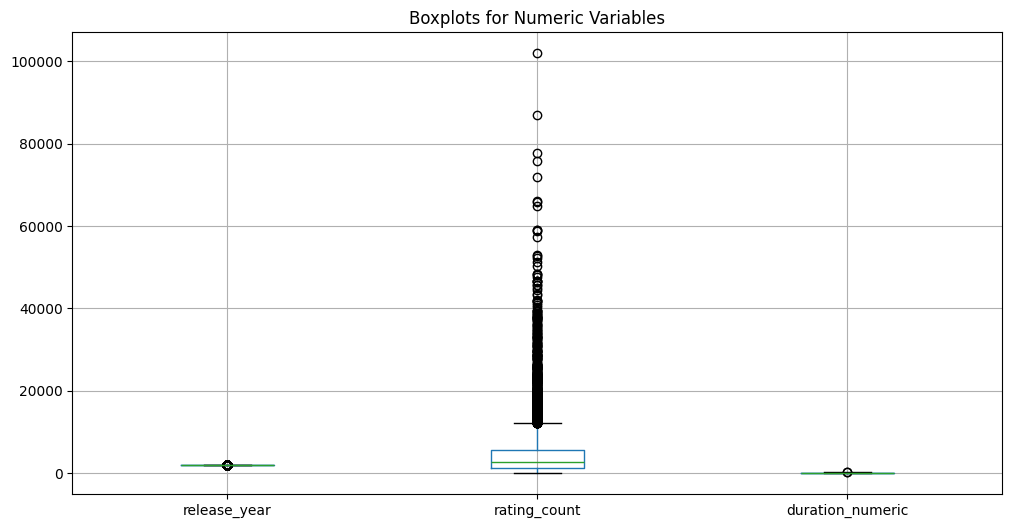

In [ ]:
# -------------------------------------------
# Boxplots for numeric variables
# -------------------------------------------

# Create a figure with a defined size for better visibility
plt.figure(figsize=(12, 6))

# Generate boxplots for the selected numeric columns
# Boxplots help identify the median, interquartile range (IQR), and potential outliers within each variable
df[numeric_cols].boxplot()

# Add a title to describe the visualisation
plt.title("Boxplots for Numeric Variables")

# Display the boxplots
plt.show()

## **STEP 4.3 — Relationships Between Variables**


### **4.3.1 Scatterplot between duration and rating_count**


Scatterplots were used to investigate the relationships between key numerical variables. The first scatterplot examined the relationship between duration_numeric and rating_count to determine whether the duration of a title influences viewer engagement. The plot showed a wide spread of values with no clear trend, suggesting that engagement is not strongly affected by duration.

A second scatterplot compared release_year with rating_count to explore whether newer or older titles receive more interaction. The distribution was again widely dispersed, indicating that viewer engagement varies considerably across all release years. Due to many titles sharing the same release year, vertical clustering appeared, which is typical for this type of data.

Overall, the scatterplots help identify whether linear or visual patterns exist between variables. In this case, both relationships appear weak, suggesting that other factors such as genre or content type, may have a stronger influence on engagement.

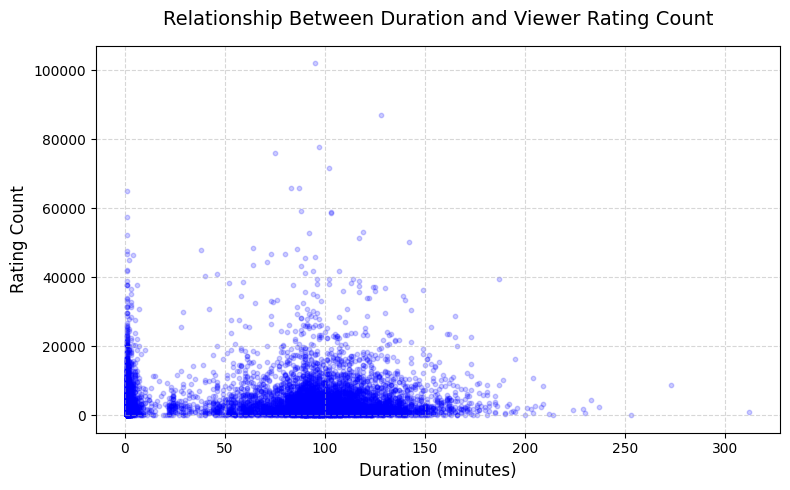

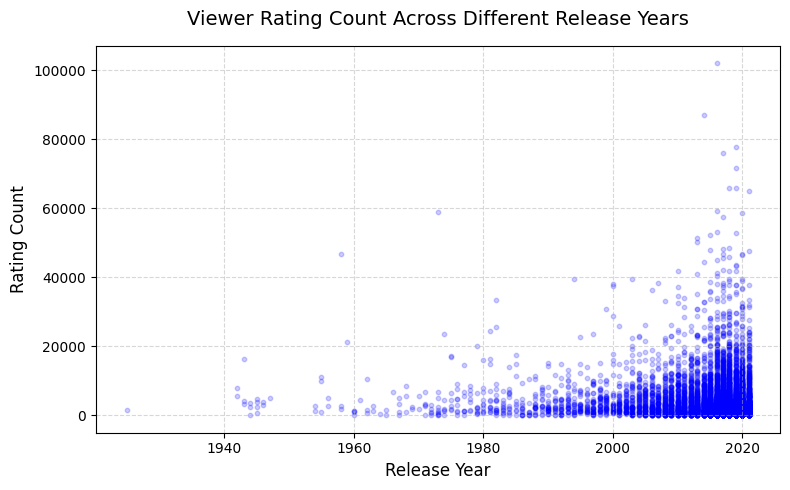

In [ ]:
# --------------------------------------------------------
# Scatterplot: Duration vs Viewer Rating Count
# --------------------------------------------------------

plt.figure(figsize=(8,5))

# Main visual
plt.scatter(df['duration_numeric'], df['rating_count'],
            alpha=0.2, s=10, color='blue')

# Main title
plt.title("Relationship Between Duration and Viewer Rating Count", fontsize=14, pad=15)

# Axis labels
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Rating Count", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# --------------------------------------------------------
# Add space between the two graphs
# --------------------------------------------------------
plt.figure(figsize=(0.1,0.1))
plt.axis('off')
plt.show()


# --------------------------------------------------------
# Scatterplot: Release Year vs Viewer Rating Count
# --------------------------------------------------------

plt.figure(figsize=(8,5))

# Main visual
plt.scatter(df['release_year'], df['rating_count'],
            alpha=0.2, s=10, color='blue')

# Main title
plt.title("Viewer Rating Count Across Different Release Years", fontsize=14, pad=15)

# Axis labels
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Rating Count", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **4.3.2 Boxplot — Genre vs Rating Count**
A boxplot was created to compare viewer engagement across different genres using the primary_genre variable. This visualisation helps identify whether certain genres tend to receive higher or lower viewer interaction by showing the distribution of rating_count for each genre. The boxplot displays the median, interquartile range, and potential outliers within each category, making it easy to spot genres with unusually high or low engagement. Colour-coding was applied to improve readability, given the large number of genre categories. Overall, this plot highlights meaningful differences across genres and helps identify which content types may be more popular on Netflix.

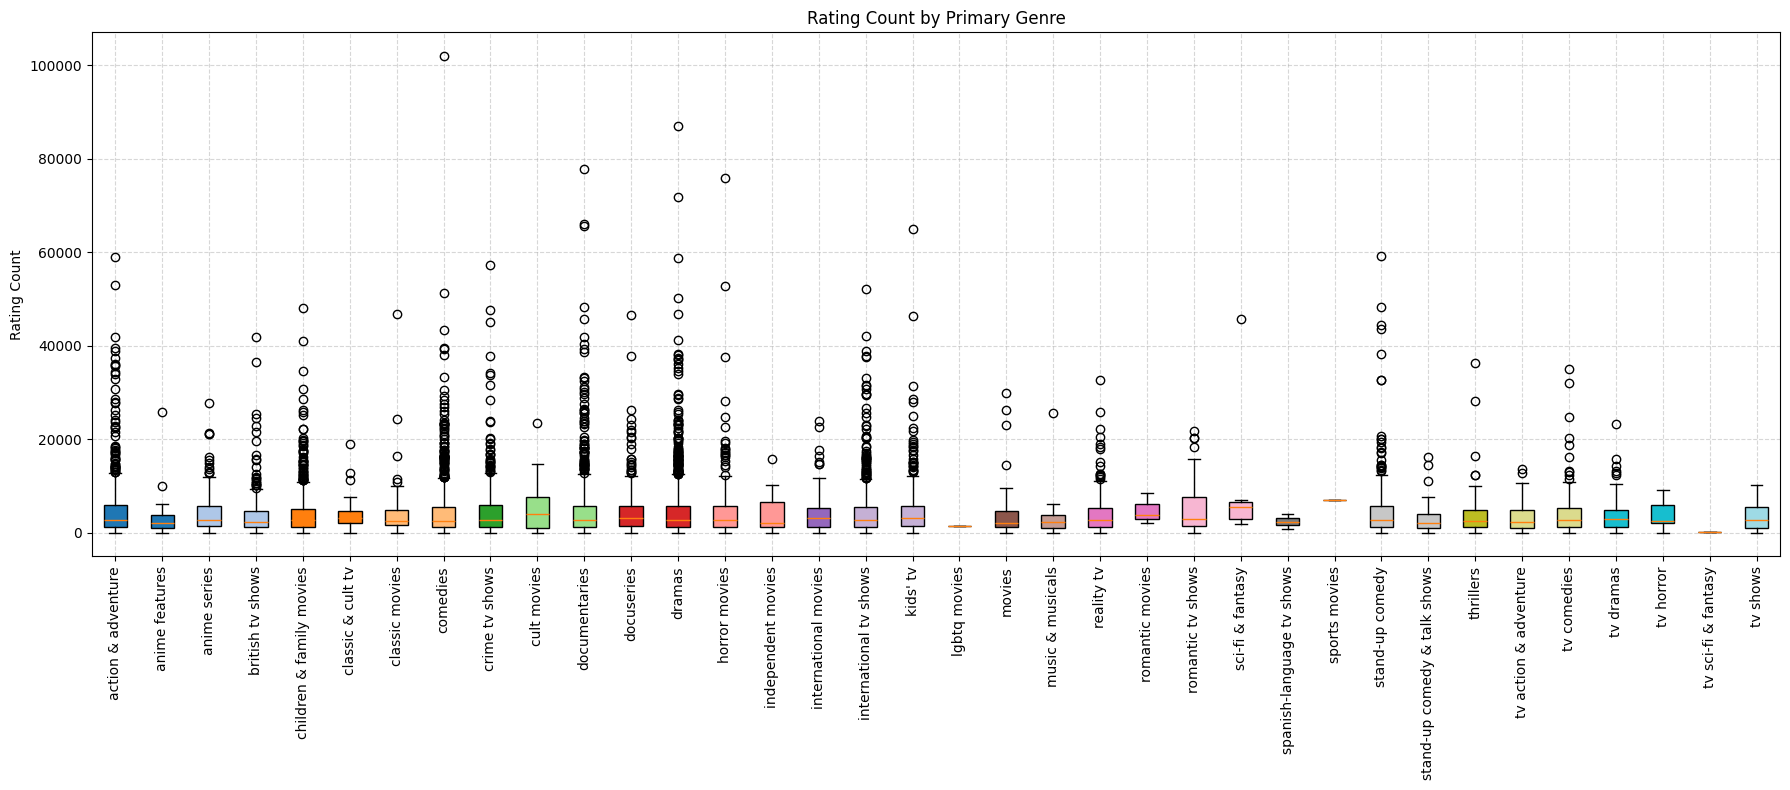

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# Boxplot: Rating Count by Primary Genre
# --------------------------------------------------------

# Set the figure size to ensure the plot is large and readable
plt.figure(figsize=(18,8))

# Step 1: Retrieve all unique genres from the 'primary_genre' column
# Sorting them alphabetically provides a consistent and organised x-axis
genres = sorted(df['primary_genre'].dropna().unique())

# Step 2: For each genre, collect all rating_count values into a list
# This creates the dataset required for generating individual boxplots
data = [df[df['primary_genre'] == g]['rating_count'].values for g in genres]

# step 3: 'tab20' provides up to 20 visually distinct colours, ideal for category plots
colors = plt.cm.tab20(np.linspace(0, 1, len(genres)))

# Step 4: Create the boxplot for all genres
# patch_artist=True allows us to fill each box with custom colours
box = plt.boxplot(data, patch_artist=True)

# Step 5: Apply a different colour to each box to improve interpretability
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Styling the plot for readability
# Add genre labels on the x-axis with rotation to prevent overlap
plt.xticks(range(1, len(genres)+1), genres, rotation=90)

# Label the y-axis to indicate what is being measured
plt.ylabel("Rating Count")

# Add a descriptive title to the plot
plt.title("Rating Count by Primary Genre")

# Add a grid to improve visual reference of values
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure proper spacing of all plot elements
plt.tight_layout()

# Display the final colourful boxplot
plt.show()




# **4.3.3  Line Chart: Number of Titles Added Per Year**
A line chart was produced to explore how the number of titles added to Netflix has changed over time. By converting date_added to a proper datetime format and extracting the year, the dataset was grouped to count how many titles were added in each year. The resulting trend line provides a clear view of Netflix’s content growth pattern. This visualisation highlights fluctuations in content addition across years and supports the time-based analysis used later in the research questions. The use of markers and gridlines helps make year-to-year changes more visible and easier to interpret.

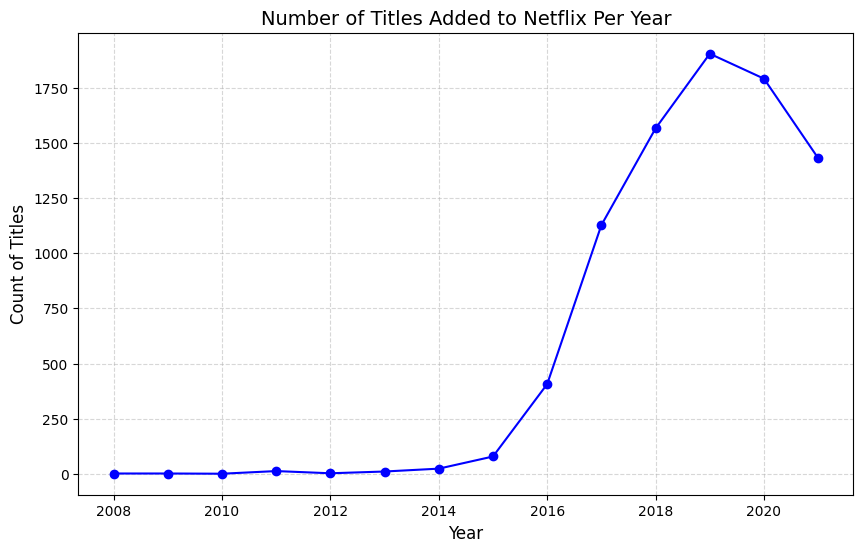

In [ ]:
# --------------------------------------------------------
# Line Chart: Number of Titles Added to Netflix Per Year
# --------------------------------------------------------

# Count how many titles were added in each year
# Sorting by index ensures the years appear in chronological order on the x-axis
titles_per_year = df['added_year'].value_counts().sort_index()

# Create a line chart to visualise trends in content addition over time
plt.figure(figsize=(10,6))
plt.plot(titles_per_year.index, titles_per_year.values, marker='o', linestyle='-', color='blue')

# Add title and axis labels for context and readability
plt.title("Number of Titles Added to Netflix Per Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count of Titles", fontsize=12)

# Add a grid for easier visual interpretation of the trend
plt.grid(True, linestyle='--', alpha=0.5)

# Display the line chart
plt.show()


# **4.4 Correlation Heatmap**
A correlation heatmap was generated to examine the relationships between key numerical variables, including release_year, rating_count, duration_numeric, added_year, and genre_count. The matrix shows that correlations between these variables are generally weak, with most values close to zero. This indicates that no strong linear relationships exist among these factors. For example, viewer engagement (rating_count) shows almost no correlation with duration or release year. The heatmap confirms that the dataset does not exhibit strong linear patterns and that viewer behaviour may depend more on non-numeric factors such as genre, content type, or platform visibility.

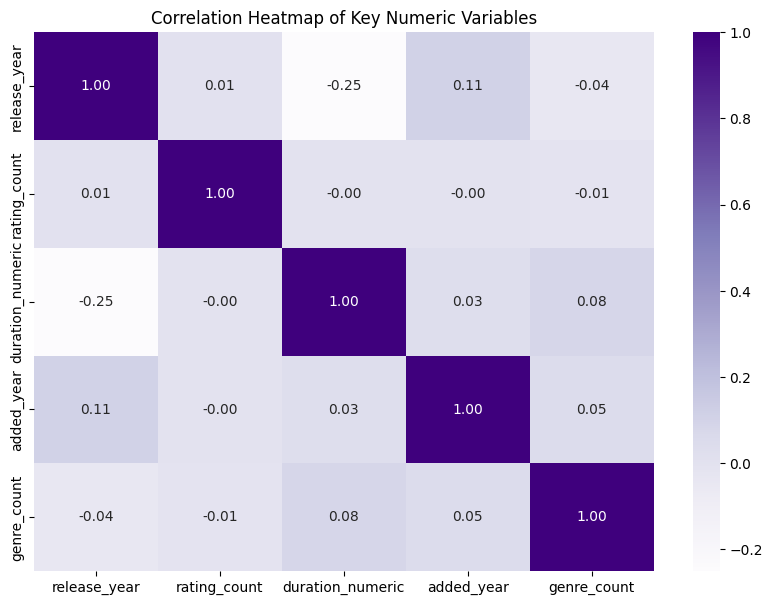

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count how many genres are assigned to each title
# Splitting the 'listed_in' string and counting elements provides a measure of genre complexity
df['genre_count'] = df['listed_in'].str.split(',').apply(len)

# Define the numeric columns to include in the correlation heatmap
# These variables represent meaningful numerical characteristics of each title
numeric_cols = [
    'release_year',
    'rating_count',
    'duration_numeric',
    'added_year',
    'genre_count'
]

plt.figure(figsize=(10,7))

# Generate a heatmap showing correlation values between selected numeric variables
# 'annot=True' displays correlation coefficients on the heatmap
# 'cmap' determines the colour theme and 'fmt' controls number formatting
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Purples', fmt=".2f")

# Add a descriptive title to the heatmap
plt.title("Correlation Heatmap of Key Numeric Variables")

# Display the heatmap
plt.show()


# **Step 5 – Research Questions**

---



## **5.1 1st Research Question :**
 Does viewer engagement on Netflix differ across different release periods, and can temporal patterns be identified?

### **5.1.1 Variables to Analyse:**


1.   release_year
2.   added_year
3.   rating_count

### **5.1.2 Type of Analysis to Conduct:**



**1.**   **Time-series Analysis:**

By aggregating the total or average rating_count per release year or added year, it becomes possible to observe how engagement changes over time. This approach helps identify long-term patterns such as increases in content popularity or shifts in user viewing behaviour.

**2.**  **Correlation Analysis:**

Calculating correlation values between release_year and rating_count allow to understand whether newer or older titles tend to attract more viewers. A positive, negative, or near-zero correlation provides insight into temporal dependencies.

**3. Rolling averages / smoothing:**

Applying moving averages over multiple years reveals whether engagement changes gradually over time rather than fluctuating sharply. This technique smooths out noise and highlights long-term patterns.

**4. Clustering of years**

Using clustering algorithms (e.g., K-means) groups release years into clusters based on engagement levels. This can uncover periods with similar viewer behaviour, such as “high engagement periods” or “low engagement periods,” offering deeper temporal insights.

## **5.2 2nd Research Question :**
 How does viewer engagement vary across different primary genres on Netflix?

### **5.2.1 Variables to Analyse:**


1.   primary_genre
2.   rating_count

### **5.2.2 Type of Analysis to Conduct:**



**1.**   **Group Comparisons:**

Comparing means, medians, and ranges of rating_count across genres shows which categories attract consistently higher engagement. This helps identify genres that perform strongly or weakly.

**2.**  **Statistical significance testing (ANOVA or Kruskal–Wallis):**

These tests examine whether differences in engagement across genres are statistically meaningful rather than occurring by chance. ANOVA is useful when engagement values are normally distributed, while Kruskal–Wallis works well for skewed distributions

**3. Genre clustering:**

Clustering genres based on their typical engagement patterns groups similar categories together. This can reveal clusters like “high-engagement genres” or “niche genres,” providing a structural understanding of content preferences.

**4. Genre popularity index:**

A combined score using metrics such as average engagement, median engagement, and the top 10% rating counts can be created. This provides a ranked list of genres, offering insights into which types of content are most appealing to viewers.

## **5.3 3rd Research Question :**
 Does the duration of a Netflix title influence its viewer engagement?

### **5.3.1 Variables to Analyse:**


1.   duration_numeric
2.   rating_count

### **5.3.2 Type of Analysis to Conduct:**



**1.**   **Correlation Analysis:**

Calculating the correlation between duration and engagement assesses whether longer or shorter titles tend to receive more ratings. This determines whether duration has any linear influence on popularity.

**2.**  **Segmentation analysis (duration categories):**

Dividing titles into meaningful duration groups such as short (<60 min), medium (60–100 min), and long (>100 min) allows comparison of engagement patterns across types of content. This can reveal whether certain duration ranges attract more consistent viewer attention.

**3. Non-linear modelling:**

Methods such as polynomial regression or decision trees can capture complex relationships that might not be linear. For example, engagement may increase up to a certain duration and decrease afterward.

**4. Interaction Analysis**

Investigating whether duration impacts engagement differently across genres or title types can reveal deeper behavioural patterns. For example, longer documentaries may behave differently from longer action films.

# **6. Conclusion :**

This project/task analysed Netflix titles by cleaning the data, creating new variables, and exploring relationships between release year, genre, duration, and viewer engagement. The findings showed that engagement varies widely but does not strongly depend on how long a title is or when it was released. Genres displayed noticeable differences, suggesting that content category influences audience interest more than age or duration.

## **6.1 Challenges :**

A key challenge in this analysis was the heavily skewed distribution of rating_count, where a small number of highly popular titles received extremely high engagement compared to the rest. These outliers were kept because they reflect genuine viewer behaviour and removing them would distort the true engagement pattern. This skewness also required careful interpretation of summary statistics and visualisations to avoid misleading conclusions.

## **6.2 Future Work:**

Future work could build on this analysis by applying predictive models to estimate engagement levels, using clustering to identify groups of similar titles, or incorporating richer metadata such as cast, country information, or user reviews. Including time-based viewing patterns or sentiment analysis could further enhance the understanding of audience behaviour on the platform.


# **Refrences**

1. CareerFoundry (2024) How to Find Outliers in Data Analytics. Available at: https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/#what-is-an-outlier
 (Accessed: 28 November 2025).

2. Datacamp (2024) Data Cleaning in Python: Handling Missing and Messy Data. Available at: https://www.datacamp.com/tutorial
 (Accessed: 25 November 2025).

3. GeeksforGeeks (2023) Handling Missing Data in Python. Available at: https://www.geeksforgeeks.org/python-pandas-handling-missing-data/
 (Accessed: 26 November 2025).

4. Google Colab (2024) Welcome to Google Colaboratory. Available at: https://colab.research.google.com/
 (Accessed: 20 November 2025).

5. Matplotlib (2024) Matplotlib: Visualization with Python. Available at: https://matplotlib.org/stable/
 (Accessed: 29 November 2025).

6. Pandas Documentation (2024) Pandas User Guide: Working with DataFrames. Available at: https://pandas.pydata.org/docs/
 (Accessed: 27 November 2025).

7. Python Software Foundation (2024) Python Language Reference. Available at: https://docs.python.org/3/
 (Accessed: 20 November 2025).

8. Real Python (2024) Guide to Using Python for Data Analysis. Available at: https://realpython.com/
 (Accessed: 25 November 2025).

9. Seaborn (2024) Seaborn Statistical Data Visualization. Available at: https://seaborn.pydata.org/
 (Accessed: 28 November 2025).

10. Towards Data Science (2023) Feature Engineering for Machine Learning. Available at: https://towardsdatascience.com/
 (Accessed: 24 November 2025).

11. W3Schools (2024) Python Pandas Tutorial. Available at: https://www.w3schools.com/python/pandas/
 (Accessed: 24 November 2025).
